### Load Kaggle MNIST dataset

In [1]:
from google.colab import drive
drive.mount('/content/drive')
MNIST_DIR  = "/content/drive/MyDrive/SHARED/Assignments/NNs/ReducedMNIST_kaggle/Reduced MNIST Data"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import torchvision.datasets as datasets
import torchvision.transforms as transforms
from pathlib import Path

# Use dataset path from Google Drive (set in Cell 3)
data_root = Path(MNIST_DIR)

train_dir = data_root / "Reduced Training data"

test_dir = data_root / "Reduced Testing data"

# basic transform (NO augmentation yet)
base_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((32, 32)),  # LeNet expects 32x32
    transforms.ToTensor(),
])

train_dataset = datasets.ImageFolder(
    root=str(train_dir),
    transform=base_transform
)

test_dataset = datasets.ImageFolder(
    root=str(test_dir),
    transform=base_transform
)

print(f"Train path: {train_dir}")
print(f"Test path: {test_dir}")

Train path: /content/drive/MyDrive/SHARED/Assignments/NNs/ReducedMNIST_kaggle/Reduced MNIST Data/Reduced Training data
Test path: /content/drive/MyDrive/SHARED/Assignments/NNs/ReducedMNIST_kaggle/Reduced MNIST Data/Reduced Testing data


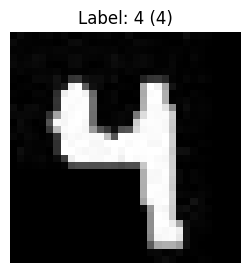

In [9]:
import matplotlib.pyplot as plt
import random

# pick a random sample from the training dataset
idx = random.randrange(len(train_dataset))
img, label = train_dataset[idx]

# show image
plt.figure(figsize=(3, 3))
plt.imshow(img.squeeze(), cmap="gray")
plt.title(f"Label: {label} ({train_dataset.classes[label]})")
plt.axis("off")
plt.show()

### Create subset
- 350 per digit
- 750 per digit
- 1000 per digit

In [10]:
from collections import defaultdict
import random
from torch.utils.data import Subset

def create_subset(dataset, samples_per_class):
    class_indices = defaultdict(list)

    # group indices by class
    for idx, (_, label) in enumerate(dataset):
        class_indices[label].append(idx)

    selected_indices = []

    for label in class_indices:
        selected = random.sample(class_indices[label], samples_per_class)
        selected_indices.extend(selected)

    return Subset(dataset, selected_indices)

### Data Augmentation

In [11]:
aug_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((32, 32)),
    transforms.RandomRotation(10),
    transforms.RandomAffine(0, translate=(0.1, 0.1)),
    transforms.ToTensor(),
])

In [15]:
augmented_dataset = datasets.ImageFolder(
    root=train_dir,
    transform=aug_transform
)

### Combine real + augmented data

In [16]:
from torch.utils.data import ConcatDataset

real_subset = create_subset(train_dataset, 350)
aug_subset = create_subset(augmented_dataset, 1000)

final_dataset = ConcatDataset([real_subset, aug_subset])

KeyboardInterrupt: 